In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [51]:
digits = load_digits()

In [52]:
def fit_predict_score(model , ds):
    return cross_val_score(model, *ds, cv=10).mean()

stump = DecisionTreeClassifier(max_depth=1)
dtree = DecisionTreeClassifier(max_depth=3)
rf = RandomForestClassifier(max_depth=1)

In [53]:
tree_classsifier = {'stump': stump, 'dtree': dtree, 'rf': rf}
max_est = 100

In [54]:
data = (digits.data, digits.target)
stump_score = fit_predict_score(stump, data)
dtree_score = fit_predict_score(dtree, data)
rf_score = [fit_predict_score(rf.set_params(n_estimators=n), data) for n in range(1, max_est + 1)]

Text(0, 0.5, 'Accuracy')

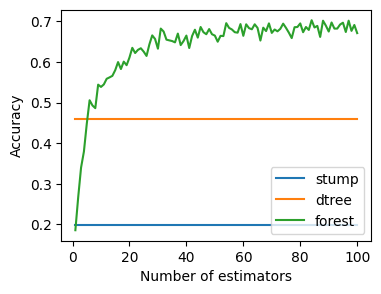

In [55]:
fig, ax = plt.subplots(figsize=(4, 3))
xs = list(range(1, max_est + 1))
ax.plot(xs, np.repeat(stump_score, max_est), label='stump')
ax.plot(xs, np.repeat(dtree_score, max_est), label='dtree')
ax.plot(xs, rf_score, label='forest')
ax.legend(loc='lower right')
ax.set_xlabel('Number of estimators')
ax.set_ylabel('Accuracy')